In [1]:
!pip install -U ultralytics sahi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 27.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.13.0.92
    Uninstalling opencv-python-4.13.0.92:
      Successfully uninstalled opencv-python-4.13.0.92
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


In [2]:
import cv2
import sahi
from ultralytics import YOLO
import shutil

import numpy as np
import pandas as pd
import os
from pathlib import Path
import glob
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Union

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
dronecam_v1_root_path = "/kaggle/input/datasets/kamrulhasan12345/dronecam-v1"  # dataset root dir
dronecam_v1_train = "/kaggle/input/datasets/kamrulhasan12345/dronecam-v1/dronecam-v1-train/images"  # train images
dronecam_v1_val: "/kaggle/input/datasets/kamrulhasan12345/dronecam-v1/dronecam-v1-val/images"    # val images
dronecam_v1_test_dev: "/kaggle/input/datasets/kamrulhasan12345/dronecam-v1/dronecam-v1-test-dev/images" # test images
dronecam_v1_test: "/kaggle/input/datasets/kamrulhasan12345/dronecam-v1/dronecam-v1-test-challenge/images"

In [4]:
models_root = "/kaggle/input/models/kamrulhasan12345/dronecam-v1-yolo/pytorch/default/1"
yolo26n_640_root_path = "/kaggle/input/models/kamrulhasan12345/dronecam-v1-yolo/pytorch/default/1/dronecam-v1-yolo26n-640-20/"
yolo26n_960_root_path = "/kaggle/input/models/kamrulhasan12345/dronecam-v1-yolo/pytorch/default/1/dronecam-v1-yolo26n-960-20/"
yolo26n_1280_root_path = "/kaggle/input/models/kamrulhasan12345/dronecam-v1-yolo/pytorch/default/1/dronecam-v1-yolo26n-1280-50/"

In [14]:
from IPython.display import Image

from sahi import AutoDetectionModel
from sahi.predict import get_prediction, get_sliced_prediction, predict
from sahi.utils.cv import read_image

from ultralytics import YOLO

In [6]:
yolo26n_640_model_path = str(Path(yolo26n_640_root_path) / 'weights' / 'best.pt')
yolo26n_960_model_path = str(Path(yolo26n_960_root_path) / 'weights' / 'best.pt')
yolo26n_1280_model_path = str(Path(yolo26n_1280_root_path) / 'weights' / 'best.pt')

In [7]:
model_type = 'ultralytics'

In [8]:
detection_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path=yolo26n_1280_model_path,  # any yolov8/yolov9/yolo11/yolo12/rt-detr/yolo26 det model is supported
    confidence_threshold=0.2,
    device="cuda:0",
)

In [9]:
challenge_image_path = '/kaggle/input/datasets/kamrulhasan12345/dronecam-v1/dronecam-v1-test-challenge/images/0000000_00098_d_0000001.jpg'

In [19]:
result = get_prediction(challenge_image_path, detection_model)

In [24]:
object_prediction_list = result.object_prediction_list
humans = [obj for obj in object_prediction_list if obj.category.name == 'human']
len(humans)

63

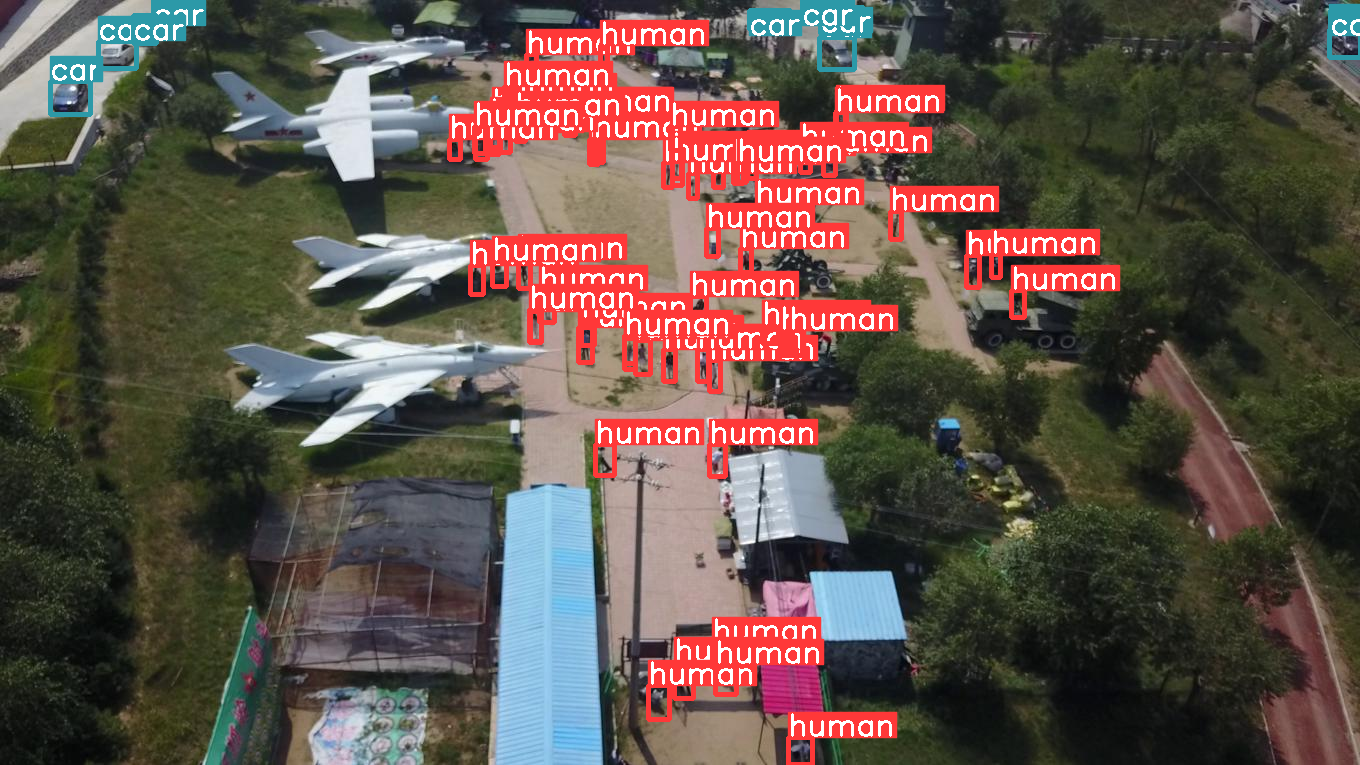

In [23]:
result.export_visuals(export_dir="test-challenge/", hide_conf=True)

Image("test-challenge/prediction_visual.png")

In [15]:
model = YOLO(yolo26n_1280_model_path)


image 1/1 /kaggle/input/datasets/kamrulhasan12345/dronecam-v1/dronecam-v1-test-challenge/images/0000000_00098_d_0000001.jpg: 736x1280 46 humans, 10 cars, 319.4ms
Speed: 7.2ms preprocess, 319.4ms inference, 0.3ms postprocess per image at shape (1, 3, 736, 1280)


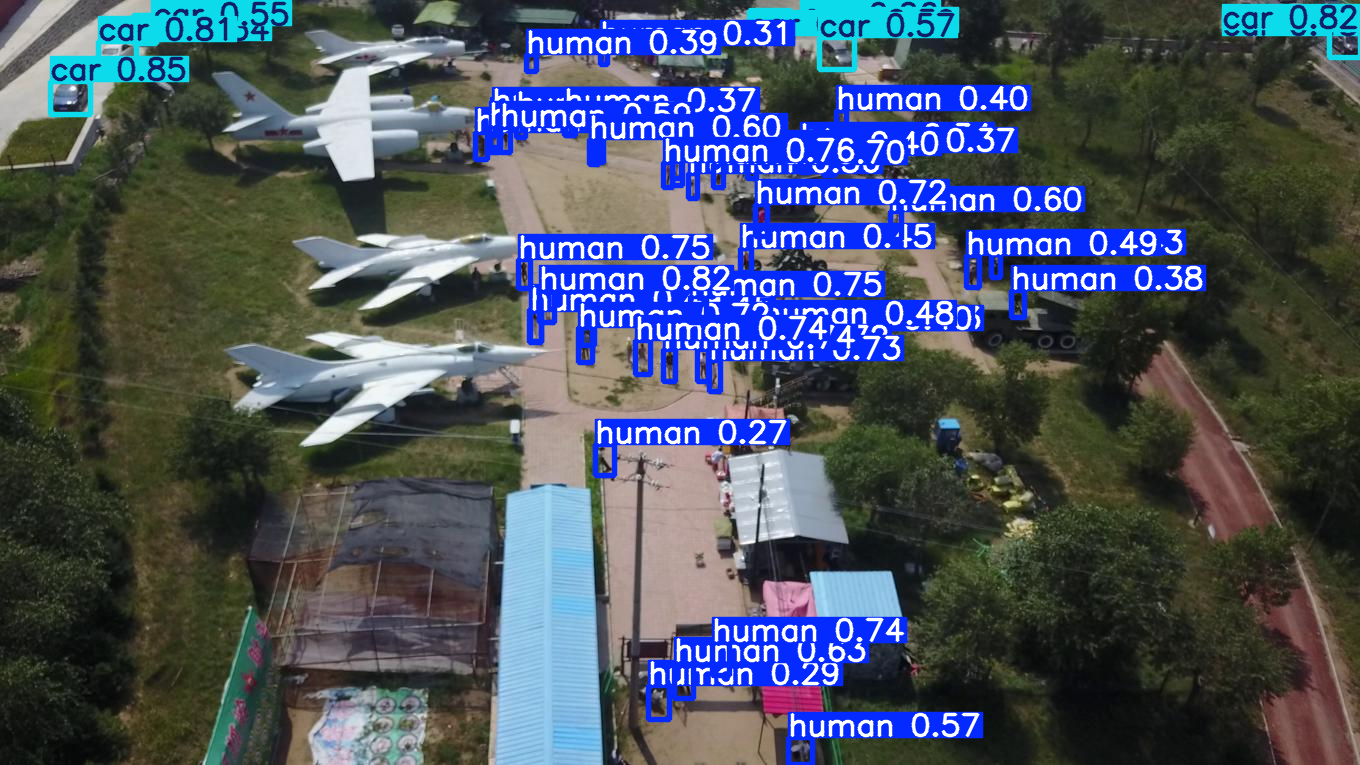

In [17]:
results = model(challenge_image_path)  # return a list of Results objects

# Process results list
for result in results:
    boxes = result.boxes  # Boxes object for bounding box outputs
    masks = result.masks  # Masks object for segmentation masks outputs
    keypoints = result.keypoints  # Keypoints object for pose outputs
    probs = result.probs  # Probs object for classification outputs
    obb = result.obb  # Oriented boxes object for OBB outputs
    result.show()  # display to screen
    result.save(filename="test-challenge/prediction_result_normal.jpg")  # save to disk